In [11]:
# Step 1: Import Librires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , confusion_matrix

In [13]:
#Step 2: Load Dataset
df=pd.read_csv("loan_dataset_20000.csv")
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [14]:
#Step 3: Understand Data
print(df.shape)
print(df.columns)
df.info()
df.describe()

(20000, 22)
Index(['age', 'gender', 'marital_status', 'education_level', 'annual_income',
       'monthly_income', 'employment_status', 'debt_to_income_ratio',
       'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate',
       'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts',
       'total_credit_limit', 'current_balance', 'delinquency_history',
       'public_records', 'num_of_delinquencies', 'loan_paid_back'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employmen

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637765,3629.136466,0.177019,679.25695,15129.300909,12.400627,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving loan_dataset_20000.csv to loan_dataset_20000.csv


In [ ]:
#Step 4: Handle Missing Values

df.isnull().sum()

,0
age,0
gender,0
marital_status,0
education_level,0
annual_income,0
monthly_income,0
employment_status,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0


In [ ]:
#Step 5: Filling Missing Values
df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].mean())
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['marital_status'] = df['marital_status'].fillna(df['marital_status'].mode()[0])
df['age'] = df['age'].fillna(df['age'].mode()[0])
df['annual_income'] = df['annual_income'].fillna(df['annual_income'].mode()[0])
df['loan_paid_back'] = df['loan_paid_back'].fillna(df['loan_paid_back'].mode()[0])



In [15]:
# Step 6: Encode Categorical Data
le = LabelEncoder()

# Identify categorical columns to encode in X (excluding the target Y and the column to be dropped)
categorical_cols_to_encode = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

for col in categorical_cols_to_encode:
  df[col] = le.fit_transform(df[col])


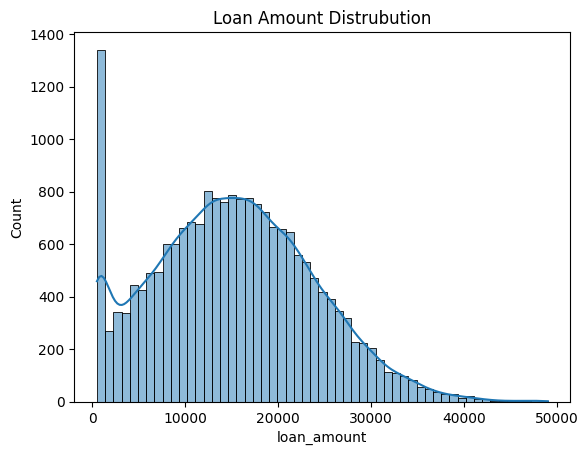

In [16]:
# Step 6: Exploratory Data Analysis
plt.figure()
sns.histplot(df['loan_amount'], kde=True)
plt.title('Loan Amount Distrubution')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


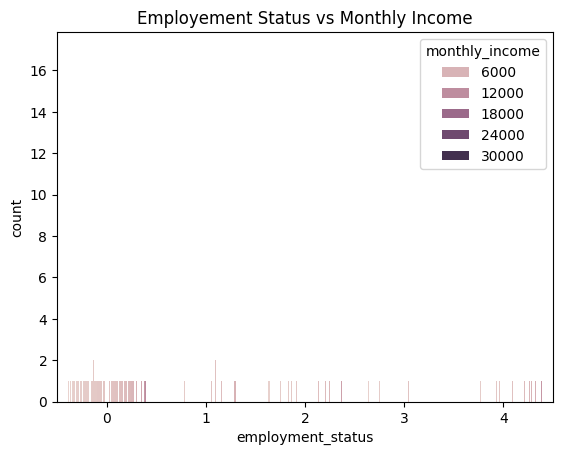

In [13]:
# Employement Status vs Moonthly Income
plt.figure()
sns.countplot(data=df, x='employment_status', hue='monthly_income')
plt.title('Employement Status vs Monthly Income')
plt.show()

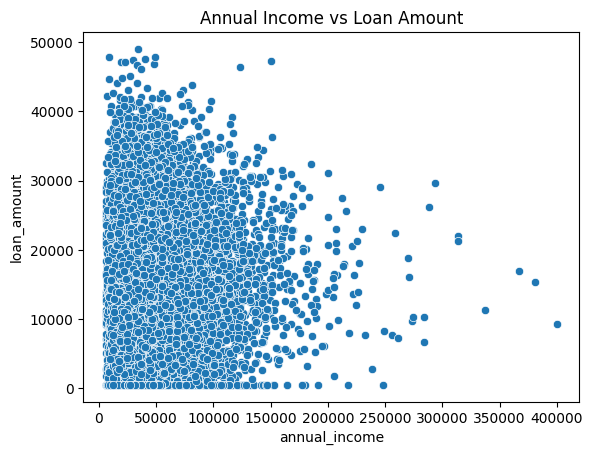

In [14]:
# Annual Income VS Loan Amount
plt.figure()
sns.scatterplot(data=df, x='annual_income', y='loan_amount', )
plt.title("Annual Income vs Loan Amount")
plt.show()

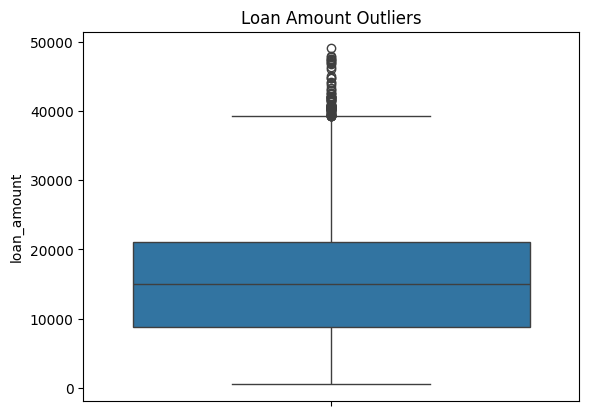

In [15]:
# BOxplot Outliers
plt.figure()
sns.boxplot(data=df, y='loan_amount')
plt.title("Loan Amount Outliers")
plt.show()

In [17]:
# Step 8 : Prepare Data For Model
X= df.drop(['current_balance'], axis=1)
Y= df['loan_paid_back']

In [18]:
# Step 9: Test_Train_Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= .2, random_state= 42)

In [24]:
# Step 10: Train Models
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)
y_pred_lr = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Step 11: Feature Scaling

To help the `LogisticRegression` model converge, we will scale the numerical features using `StandardScaler`. This will transform the features to have a mean of 0 and a standard deviation of 1.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Identify numerical columns for scaling
# Exclude already encoded categorical columns and the target variable
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Apply scaling only to numerical columns
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("X_train_scaled head:")
display(X_train_scaled.head())
print("X_test_scaled head:")
display(X_test_scaled.head())

X_train_scaled head:


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,interest_rate,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
5894,-1.076666,-0.962241,0.842416,-0.051231,-0.709495,-0.709494,-0.642492,-0.800628,0.775974,1.069496,...,-0.165502,-0.654946,1.284861,-0.196586,0.001643,-0.719000,-1.357122,-0.216989,-1.535474,0.498437
3728,-1.582588,0.893800,-0.658548,-0.945112,-0.264992,-0.264991,-0.642492,-0.771998,0.200957,1.203755,...,-0.350208,-0.654946,1.404660,-0.682133,-0.443873,0.141860,-1.357122,-0.216989,-1.535474,0.498437
8958,1.326465,-0.962241,0.842416,-0.945112,-0.372113,-0.372113,0.812344,-0.581129,1.796629,-1.708913,...,-2.131594,-0.654946,-1.612119,-1.976925,-0.443873,-0.723762,-0.676605,-0.216989,0.308893,0.498437
7671,1.073504,0.893800,-0.658548,-0.051231,-0.298975,-0.298973,-0.642492,-1.315973,-0.000299,0.346757,...,-0.502077,-0.654946,0.506454,-0.034737,-0.443873,-0.313464,-0.676605,-0.216989,-0.920685,0.498437
5999,1.579426,-0.962241,0.842416,-0.945112,-0.957034,-0.957033,-0.642492,-0.199392,-0.230306,0.244276,...,0.955047,-0.654946,0.508793,0.612659,-0.889389,-0.993656,-0.676605,-0.216989,-0.305896,0.498437


X_test_scaled head:


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,interest_rate,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
10650,0.883783,-0.962241,0.842416,-0.945112,-0.442927,-0.442928,-0.642492,-1.363690,-0.489064,0.094311,...,0.897583,-0.654946,0.342469,0.127112,0.001643,-0.710807,-0.676605,-0.216989,-0.305896,0.498437
2041,-1.329627,-0.962241,0.842416,-0.945112,0.072525,0.072527,-0.642492,0.793124,0.646595,0.376965,...,-0.629319,1.526844,-0.211651,-0.196586,-1.334906,0.480373,-0.676605,-0.216989,-0.305896,0.498437
8668,-1.203146,-0.962241,0.842416,-0.051231,-0.067325,-0.067326,-0.642492,-0.810171,-1.725350,-0.137331,...,0.269583,-0.654946,0.054299,2.392999,-0.889389,0.297270,0.684430,-0.216989,0.923682,0.498437
1114,-1.392867,-0.962241,-2.159513,-0.945112,1.719469,1.719468,-0.642492,0.048737,-1.322838,1.216891,...,2.211048,-0.654946,1.703320,1.260055,0.001643,1.797513,-0.676605,-0.216989,-0.920685,0.498437
13902,-0.001581,-0.962241,2.343381,0.842651,-0.445944,-0.445946,-0.642492,-1.430494,-0.445937,-1.129058,...,0.700564,-0.654946,-0.983955,0.127112,0.447159,-0.105808,-0.676605,-0.216989,-0.305896,0.498437


In [26]:
# Logistic Regression with scaled data
lr_scaled = LogisticRegression(max_iter=2000) # Increased max_iter already, keeping it for scaled data
lr_scaled.fit(X_train_scaled, Y_train)

y_pred_lr_scaled = lr_scaled.predict(X_test_scaled)

# Evaluate the model
print("Logistic Regression Accuracy with Scaled Data:", accuracy_score(Y_test, y_pred_lr_scaled))
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred_lr_scaled))

Logistic Regression Accuracy with Scaled Data: 1.0

Confusion Matrix:
[[ 818    0]
 [   0 3182]]


In [27]:
# Decision Tree Classifier
dt=DecisionTreeClassifier()
dt.fit(X_train, Y_train)
y_pred_dt= dt.predict(X_test)

In [30]:
# Step 11: Evaluate Model
print("Logistic Regression accuracy:", accuracy_score(Y_test, y_pred_lr))
print("Decision Tree accuracy:", accuracy_score(Y_test, y_pred_dt))

Logistic Regression accuracy: 0.885
Decision Tree accuracy: 1.0


In [32]:
# Confusion Matrix
print("Confusion Matrix(Logistic Regression)")
print(confusion_matrix(Y_test, y_pred_lr))

print("Confusion Matrix(Decision Tree)")
print(confusion_matrix(Y_test, y_pred_dt))

Confusion Matrix(Logistic Regression)
[[ 470  348]
 [ 112 3070]]
Confusion Matrix(Decision Tree)
[[ 818    0]
 [   0 3182]]
